In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

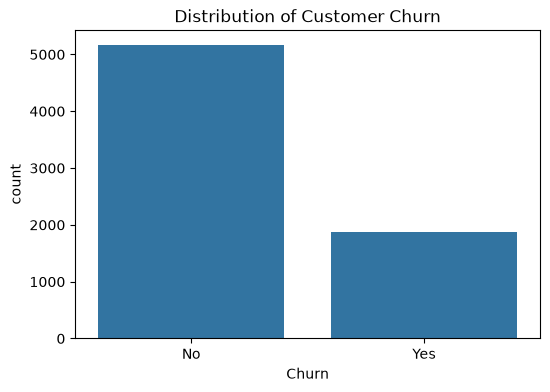

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.show()

### Observation

- Majority of customers did not churn.
- The dataset is moderately imbalanced.
- This should be considered during model evaluation.
- Accuracy alone may not be a sufficient evaluation metric; precision, recall, and F1-score should also be considered during model evaluation.

In [7]:
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["str"]).columns.tolist()

In [8]:
print(df.dtypes.unique())

[<StringDtype(na_value=nan)> dtype('int64') dtype('float64')]


In [9]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [10]:
categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
# Remove identifier column
categorical_features.remove("customerID")

# Treat binary variable as categorical
numerical_features.remove("SeniorCitizen")
categorical_features.append("SeniorCitizen")

# Numerical Feature Analysis

This section explores the distribution and characteristics of numerical features in the dataset.

In [12]:
numerical_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [13]:
df['tenure'].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

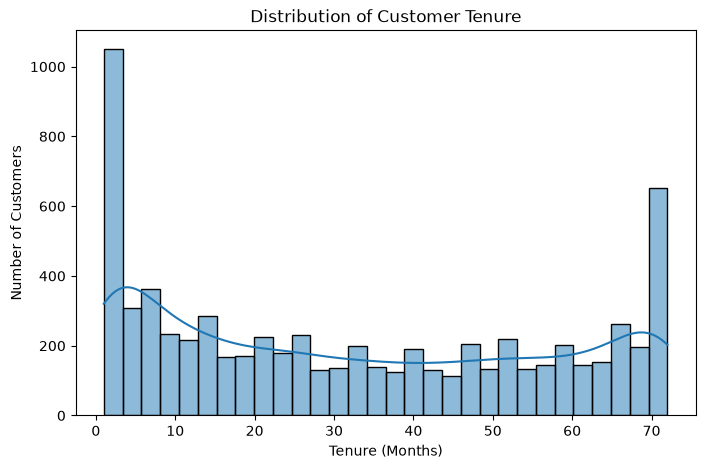

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

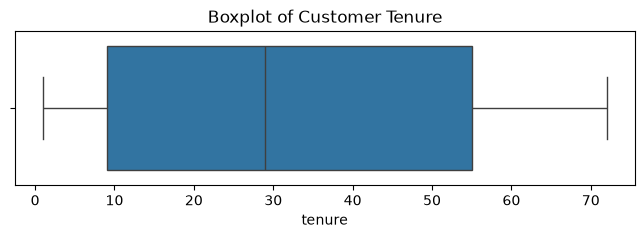

In [26]:
plt.figure(figsize=(8,2))

sns.boxplot(data=df,x="tenure")
plt.title("Boxplot of Customer Tenure")
plt.show()

### Observations

- Customer tenure ranges from 1 to 72 months.
- Most customers have relatively low tenure.
- Another concentration exists near the maximum tenure.
- The distribution is not perfectly symmetric.

In [27]:
df['MonthlyCharges'].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

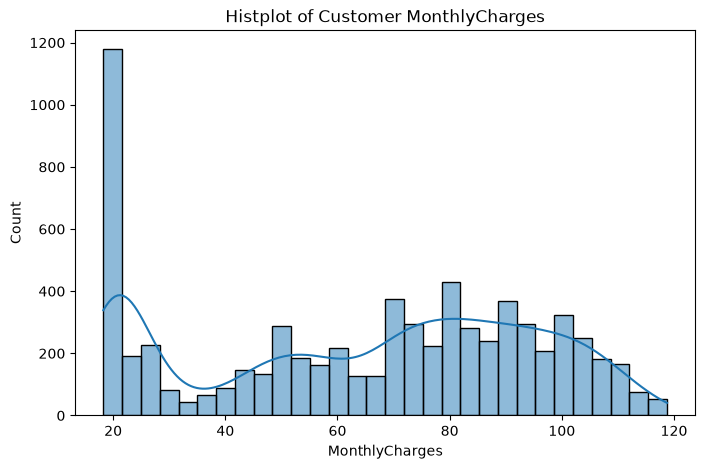

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True)
plt.title("Distribution  of Customer MonthlyCharges")

plt.show()

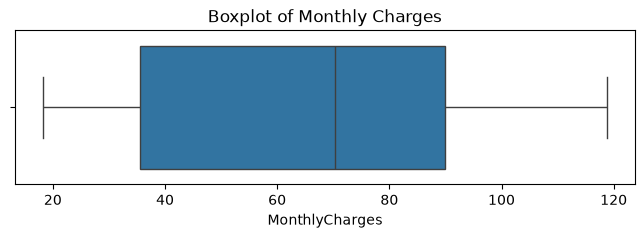

In [30]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="MonthlyCharges"
)

plt.title("Boxplot of Monthly Charges")
plt.show()

### Observations

- Monthly charges vary across a wide range.
- The distribution is slightly skewed.
- The boxplot does not indicate a large number of extreme outliers.
- Most customers fall within the central range of monthly charges.

In [31]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

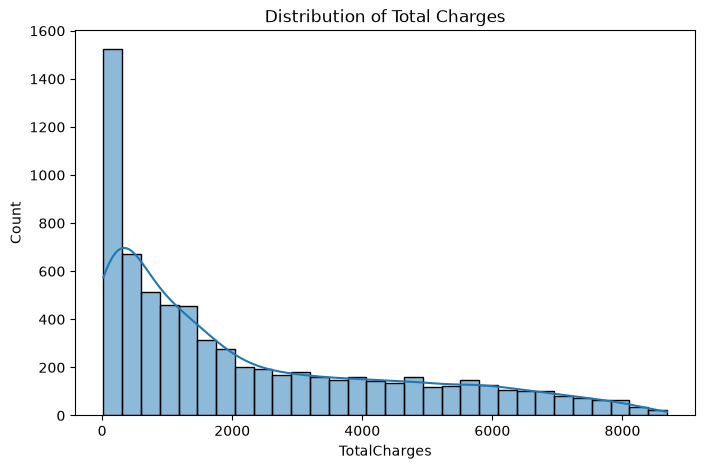

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df, x="TotalCharges", bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.show()

### Observations

- Total charges exhibit a wide spread among customers.
- The distribution is positively skewed.
- Higher total charges are observed for a smaller number of customers.
- A few high-value observations appear in the boxplot.